In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn import tree
from sklearn import cluster
from sklearn import decomposition
from sklearn import svm
from sklearn import ensemble
from sklearn import neighbors
from sklearn import naive_bayes
from sklearn import metrics
import seaborn as sns
import pickle

In [2]:
data = pd.read_csv("Instagram_fake_profile_dataset.csv")
data

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
0,1,0.270000,0,0.000000,0,53,0,0,32,1000,955,0
1,1,0.000000,2,0.000000,0,44,0,0,286,2740,533,0
2,1,0.100000,2,0.000000,0,0,0,1,13,159,98,0
3,1,0.000000,1,0.000000,0,82,0,0,679,414,651,0
4,1,0.000000,2,0.000000,0,0,0,1,6,151,126,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0,0.258135,0,0.000000,0,0,0,1,7,1,217,1
4996,0,0.511986,1,0.000000,0,0,0,0,0,51,24,1
4997,0,0.473108,1,0.353231,0,0,0,0,0,20,0,1
4998,0,0.293326,1,0.000000,0,0,0,0,75,1314,5120,1


## Preprocessing

In [3]:
data.head(10)

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
0,1,0.27,0,0.0,0,53,0,0,32,1000,955,0
1,1,0.00,2,0.0,0,44,0,0,286,2740,533,0
2,1,0.10,2,0.0,0,0,0,1,13,159,98,0
3,1,0.00,1,0.0,0,82,0,0,679,414,651,0
4,1,0.00,2,0.0,0,0,0,1,6,151,126,0
5,1,0.00,4,0.0,0,81,1,0,344,669987,150,0
6,1,0.00,2,0.0,0,50,0,0,16,122,177,0
7,1,0.00,2,0.0,0,0,0,0,33,1078,76,0
8,1,0.00,0,0.0,0,71,0,0,72,1824,2713,0
9,1,0.00,2,0.0,0,40,1,0,213,12945,813,0


In [4]:
data.tail(10)

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
4990,0,0.434876,1,0.270288,0,0,0,0,2,51,60,1
4991,0,0.221793,0,0.000000,0,0,0,1,14,4,215,1
4992,0,0.364507,1,0.396203,0,0,0,0,4,107,234,1
4993,1,0.423267,0,0.000000,0,0,0,1,0,19,76,1
4994,0,0.057575,1,0.000000,0,0,0,0,0,2,599,1
4995,0,0.258135,0,0.000000,0,0,0,1,7,1,217,1
4996,0,0.511986,1,0.000000,0,0,0,0,0,51,24,1
4997,0,0.473108,1,0.353231,0,0,0,0,0,20,0,1
4998,0,0.293326,1,0.000000,0,0,0,0,75,1314,5120,1
4999,0,0.605471,1,0.016533,0,1,0,0,0,57,344,1


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   profile pic           5000 non-null   int64  
 1   nums/length username  5000 non-null   float64
 2   fullname words        5000 non-null   int64  
 3   nums/length fullname  5000 non-null   float64
 4   name==username        5000 non-null   int64  
 5   description length    5000 non-null   int64  
 6   external URL          5000 non-null   int64  
 7   private               5000 non-null   int64  
 8   #posts                5000 non-null   int64  
 9   #followers            5000 non-null   int64  
 10  #follows              5000 non-null   int64  
 11  fake                  5000 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 468.9 KB


In [6]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
profile pic,5000.0,0.598200,0.490311,0.0,0.0,1.000000,1.00000,1.00
nums/length username,5000.0,0.166175,0.194733,0.0,0.0,0.089193,0.30041,0.92
fullname words,5000.0,1.212800,0.890435,0.0,1.0,1.000000,2.00000,12.00
nums/length fullname,5000.0,0.036068,0.106235,0.0,0.0,0.000000,0.00000,1.00
name==username,5000.0,0.007600,0.086855,0.0,0.0,0.000000,0.00000,1.00
description length,5000.0,20.997200,33.234706,0.0,0.0,1.000000,31.25000,150.00
external URL,5000.0,0.049600,0.217139,0.0,0.0,0.000000,0.00000,1.00
private,5000.0,0.227800,0.419455,0.0,0.0,0.000000,0.00000,1.00
#posts,5000.0,103.331400,377.804886,0.0,0.0,10.000000,81.00000,7389.00
#followers,5000.0,51244.352000,596374.900095,0.0,40.0,145.000000,696.00000,15338538.00


In [7]:
data.isnull().sum()

profile pic             0
nums/length username    0
fullname words          0
nums/length fullname    0
name==username          0
description length      0
external URL            0
private                 0
#posts                  0
#followers              0
#follows                0
fake                    0
dtype: int64

In [8]:
for c in data.columns:
  print(data[c].value_counts())
  print("--------------------")

profile pic
1    2991
0    2009
Name: count, dtype: int64
--------------------
nums/length username
0.000000    1848
0.330000      36
0.400000      19
0.440000      19
0.250000      15
            ... 
0.369476       1
0.452369       1
0.155907       1
0.285438       1
0.035967       1
Name: count, Length: 2877, dtype: int64
--------------------
fullname words
1     2970
2     1147
0      679
3      128
4       40
5       12
7        8
8        5
6        3
10       3
9        2
11       2
12       1
Name: count, dtype: int64
--------------------
nums/length fullname
0.000000    4128
0.330000      14
0.400000       9
0.310000       7
0.250000       4
            ... 
0.127617       1
0.270288       1
0.396203       1
0.353231       1
0.110063       1
Name: count, Length: 829, dtype: int64
--------------------
name==username
0    4962
1      38
Name: count, dtype: int64
--------------------
description length
0      2479
1       122
2        70
3        50
8        47
       ... 
114   

## Visualization

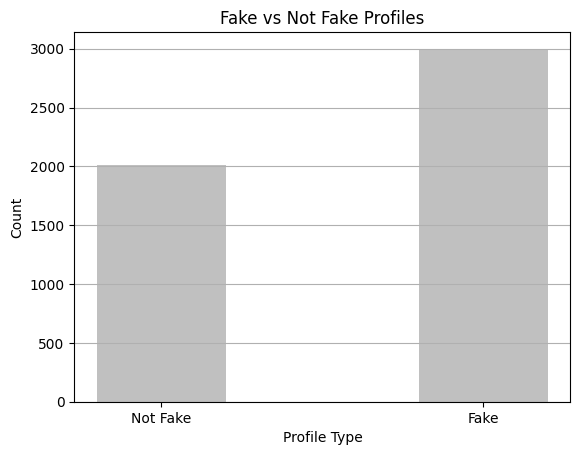

In [9]:
counts = data["profile pic"].value_counts().sort_index()
labels = ["Not Fake","Fake"]

plt.bar(labels, counts.values,width=0.4, color = "silver")
plt.xlabel("Profile Type")
plt.ylabel("Count")
plt.title("Fake vs Not Fake Profiles")
plt.grid(axis="y")
plt.savefig("profile pic.png")
plt.show()

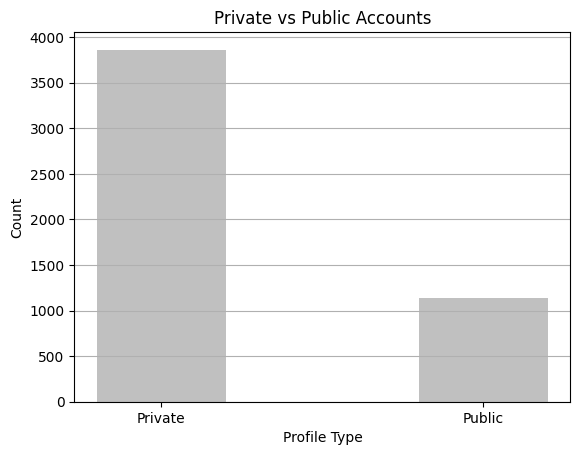

In [10]:
counts = data["private"].value_counts().sort_index()
labels = ["Private","Public"]

plt.bar(labels, counts.values,width=0.4, color = "silver")
plt.xlabel("Profile Type")
plt.ylabel("Count")
plt.title("Private vs Public Accounts")
plt.grid(axis="y")
plt.savefig("account type.png")
plt.show()

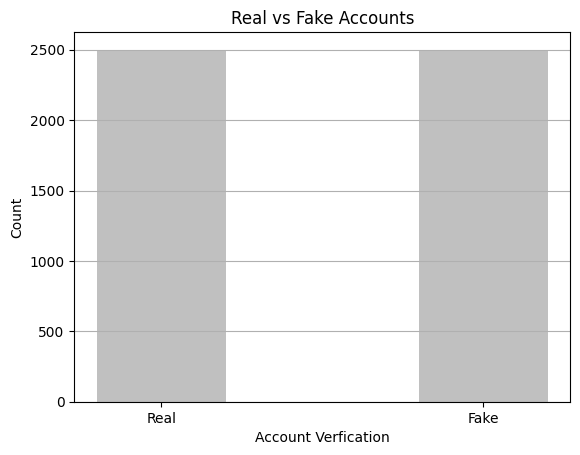

In [11]:
counts = data["fake"].value_counts().sort_index()
labels = ["Real","Fake"]

plt.bar(labels, counts.values,width=0.4, color = "silver")
plt.xlabel("Account Verfication")
plt.ylabel("Count")
plt.title("Real vs Fake Accounts")
plt.grid(axis="y")
plt.savefig("account verfication.png")
plt.show()

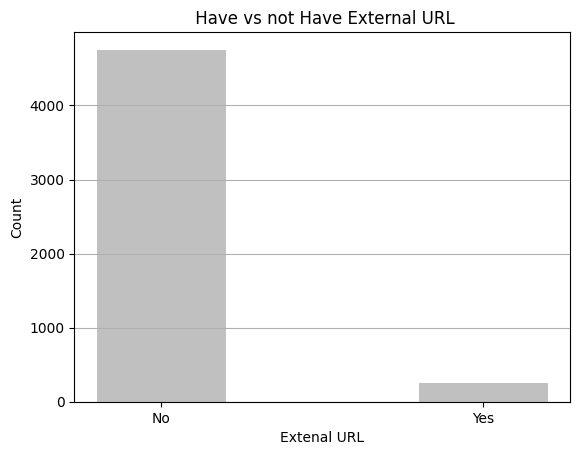

In [12]:
counts = data["external URL"].value_counts().sort_index()
labels = ["No","Yes"]

plt.bar(labels, counts.values,width=0.4, color = "silver")
plt.xlabel("Extenal URL")
plt.ylabel("Count")
plt.title(" Have vs not Have External URL")
plt.grid(axis="y")
plt.savefig("extenal url.png")
plt.show()

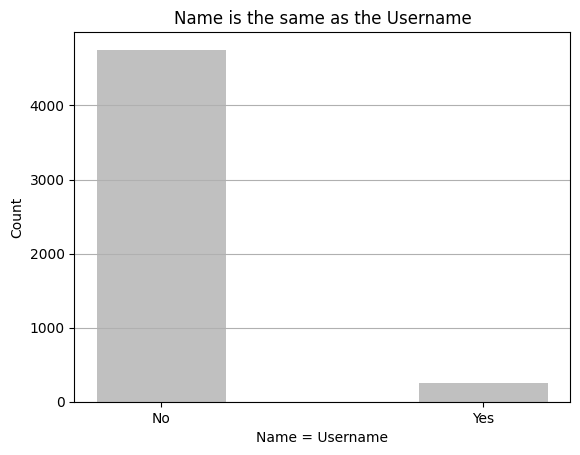

In [13]:
counts = data["external URL"].value_counts().sort_index()
labels = ["No","Yes"]

plt.bar(labels, counts.values,width=0.4, color = "silver")
plt.xlabel("Name = Username")
plt.ylabel("Count")
plt.title("Name is the same as the Username")
plt.grid(axis="y")
plt.savefig("name and username.png")
plt.show()

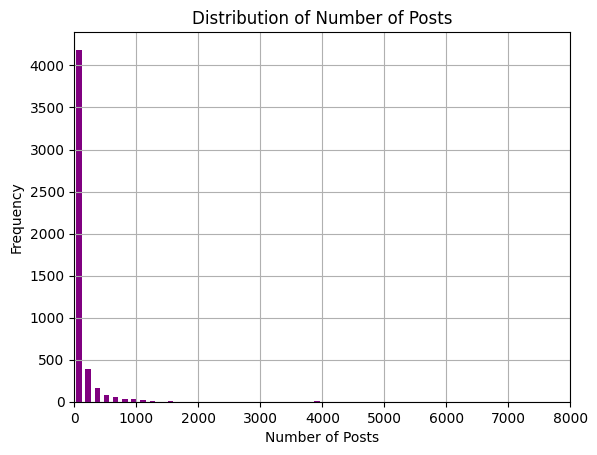

In [14]:
plt.hist(data["#posts"],bins=50,rwidth=0.6, color="purple")
plt.xlim(0,8000)
plt.xlabel("Number of Posts")
plt.ylabel("Frequency")
plt.title("Distribution of Number of Posts")
plt.grid()
plt.savefig("number of posts.png")
plt.show()

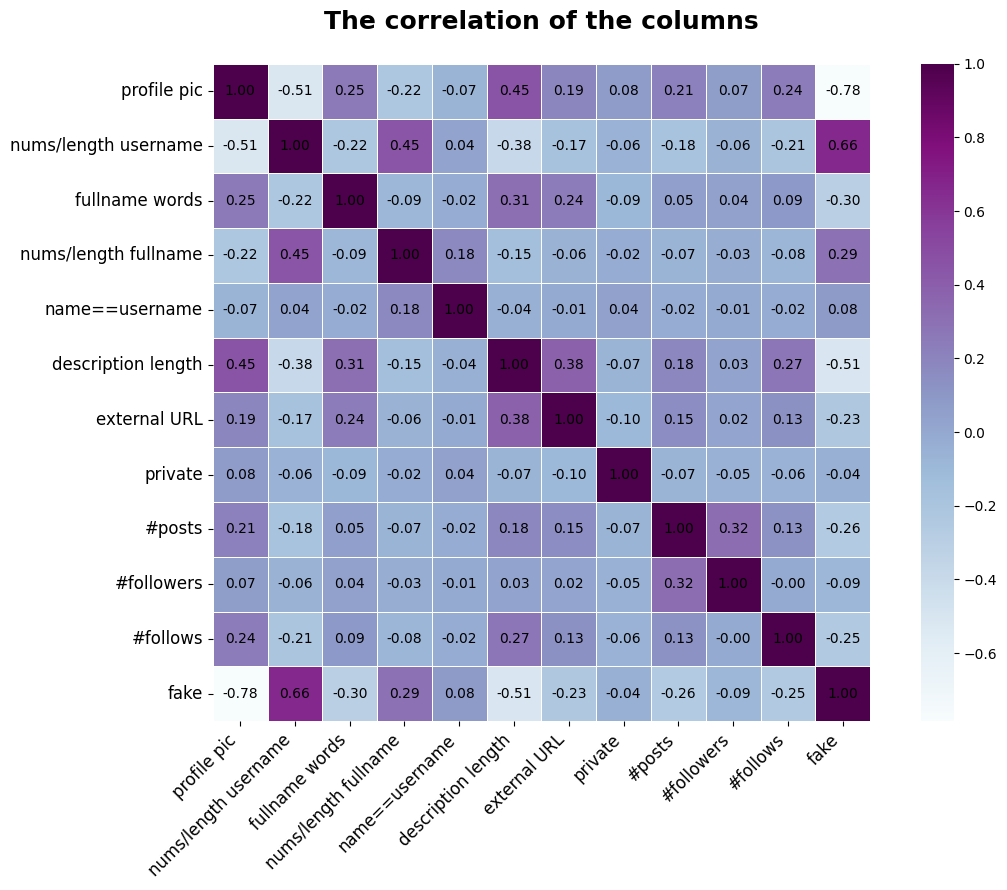

In [15]:
# correlation: whether a feature changes when another feature changes

# positive corr : both increase or decrease together
# If the number of rooms increases, the house price increases

# negative corr : one increases, the other one decreases

# zero corr : they have no clear relationship

# why is correlation important?
# the good features are the ones that have a correlation close to 1 or -1 with the output
# the not very good features are the ones that have a correlation close to 0

plt.figure(figsize=(12, 9))

cmap = sns.color_palette("BuPu", as_cmap=True) # blue-purple pastel

sns.heatmap(
 data.corr(),
 annot=True,
 fmt=".2f",
 cmap=cmap,
 cbar=True,
 linewidths=0.5,
 linecolor='white',
 annot_kws={"color": "black"},
 square=True
)

plt.title("The correlation of the columns", fontsize=18, color='black', pad=25, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12, color='black')
plt.yticks(rotation=0, fontsize=12, color='black')
plt.tight_layout()
plt.savefig("correlation.png")
plt.show()

##split the *data*

In [16]:
x = data.drop("fake" , axis=1)
y = data["fake"]

In [17]:
#we split the data into train and test.
# we keep 80 percent for train and 20 percent for test (test _size=0.2)

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# Classification Models

In [18]:
model_log = linear_model.LogisticRegression()


# train the model
model_log.fit(x_train,y_train)

# test the model
y_log = model_log.predict(x_test)

# calculate the accuracy
acc_log = metrics.accuracy_score(y_test,y_log)
print(acc_log*100)

#save the model
with open ("model_log.pkl","wb") as f:
  pickle.dump(model_log,f)

93.89999999999999


c:\Users\Maryam\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [19]:
model_tree = tree.DecisionTreeClassifier()


# train the model
model_tree.fit(x_train,y_train)

# test the model
y_tree = model_tree.predict(x_test)

# calculate the accuracy
acc_tree = metrics.accuracy_score(y_test,y_tree)
print(acc_tree*100)

#save the model
with open ("model_tree.pkl","wb") as f:
  pickle.dump(model_tree,f)

97.1


In [20]:
model_forest = ensemble.RandomForestClassifier()


# train the model
model_forest.fit(x_train,y_train)

# test the model
y_forest = model_forest.predict(x_test)

# calculate the accuracy
acc_forest = metrics.accuracy_score(y_test,y_forest)
print(acc_forest*100)

#save the model
with open ("model_forest.pkl","wb") as f:
  pickle.dump(model_forest,f)

98.9


In [21]:
model_svm = svm.SVC()


# train the model
model_svm.fit(x_train,y_train)

# test the model
y_svm = model_svm.predict(x_test)

# calculate the accuracy
acc_svm = metrics.accuracy_score(y_test,y_svm)
print(acc_svm*100)

#save the model
with open ("model_svm.pkl","wb") as f:
  pickle.dump(model_svm,f)

53.900000000000006


In [22]:
model_knn = neighbors.KNeighborsClassifier()


# train the model
model_knn.fit(x_train,y_train)

# test the model
y_knn = model_knn.predict(x_test)

# calculate the accuracy
acc_knn = metrics.accuracy_score(y_test,y_knn)
print(acc_knn*100)

#save the model
with open ("model_knn.pkl","wb") as f:
  pickle.dump(model_knn,f)

95.39999999999999


In [23]:
model_nb = naive_bayes.CategoricalNB()


# train the model
model_nb.fit(x_train,y_train)

# test the model
y_nb = model_nb.predict(x_test)

# calculate the accuracy
acc_nb = metrics.accuracy_score(y_test,y_nb)
print(acc_nb*100)

#save the model
with open ("model_nb.pkl","wb") as f:
  pickle.dump(model_nb,f)

92.60000000000001


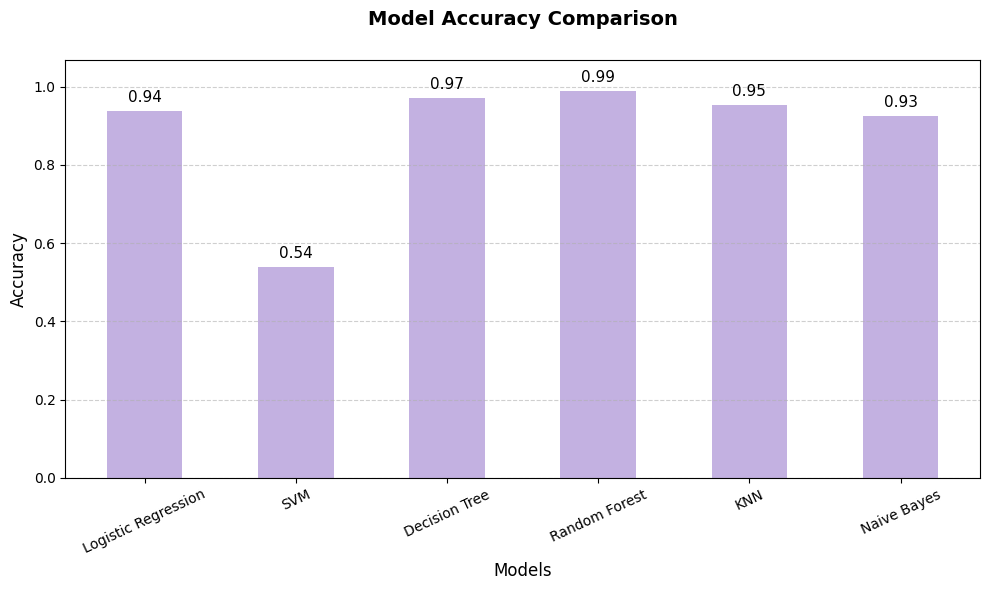

In [24]:
import matplotlib.pyplot as plt

# Model names
models = [
    "Logistic Regression",
    "SVM",
    "Decision Tree",
    "Random Forest",
    "KNN",
    "Naive Bayes"
]

# Accuracies
accuracies = [
    acc_log,
    acc_svm,
    acc_tree,
    acc_forest,
    acc_knn,
    acc_nb
]

plt.figure(figsize=(10, 6))

# Pastel purple color
bars = plt.bar(models, accuracies, width=0.5, color="#C3B1E1")

plt.title("Model Accuracy Comparison", fontsize=14, fontweight="bold", pad=25)
plt.xlabel("Models", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.ylim(0, max(accuracies) + 0.08)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.015,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.xticks(rotation=25)
plt.tight_layout()

plt.savefig("model_accuracy_comparison.png")

plt.show()